# Environment Check

## What you will learn
How to verify a classroom runtime, distinguish core dependencies from optional research packages, and write a first artifact.

## Codes used
Core Python stack; optional imports for JAX, VMEC-JAX, Boozer, NEO, SFINCS-JAX, SPECTRAX-GK, SIMSOPT, NEOPAX, and ESSOS.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
Package-status table, backend notes, folder checks, and `assets/figures/environment_check.png`.

## What this teaches

The object is the classroom runtime itself: core imports, optional imports, writable folders, and one generated plot.

## What this does not prove

It does not prove that every research package can run a meaningful scientific calculation on this machine.

## Literature anchor

The first reproducibility lesson is mundane but important: a credible optimization result is an artifact with package versions, data provenance, and a rerunnable path. This notebook connects the live environment to `STATUS.md`, the figure manifest, and the ReadTheDocs build rather than treating imports as scientific validation.

## Reference-deck connection

The source decks separate reliable classroom objects from research calculations. This notebook checks that the same split works on the current machine before any live demo begins.

The PowerPoint decks keep the polished visual argument; this notebook keeps the runnable computational object behind it.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Why this notebook exists

A school repository must survive many laptops. The scientific stack is valuable, but the lecture should not fail if a compiled package is absent. This first notebook separates the robust teaching layer from optional research packages.

In [5]:
import platform
print("Python", platform.python_version())
print("Platform", platform.platform())

Python 3.11.14
Platform macOS-14.4.1-arm64-arm-64bit


## 2. Core packages are required

These packages define cached mode. If any of them fail, the classroom environment is not ready.

In [6]:
core_modules = ["numpy", "scipy", "matplotlib", "pandas", "xarray", "netCDF4", "h5py", "nbformat", "nbconvert", "pytest"]
rows = []
for name in core_modules:
    try:
        module = importlib.import_module(name)
        rows.append({"module": name, "required": True, "status": "OK", "version": getattr(module, "__version__", "unknown")})
    except Exception as exc:
        rows.append({"module": name, "required": True, "status": "FAIL", "version": f"{type(exc).__name__}: {exc}"})
core_df = pd.DataFrame(rows)
core_df

,module,required,status,version
0,numpy,True,OK,2.4.4
1,scipy,True,OK,1.17.1
2,matplotlib,True,OK,3.10.8
3,pandas,True,OK,3.0.2
4,xarray,True,OK,2025.3.0
5,netCDF4,True,OK,1.7.3
6,h5py,True,OK,3.16.0
7,nbformat,True,OK,5.10.4
8,nbconvert,True,OK,7.16.4
9,pytest,True,OK,9.0.3


## 3. Optional packages are research accelerators

A missing optional package is not a lecture failure. It only decides whether a notebook can use `research` mode.

In [7]:
optional_modules = {
    "JAX": "jax",
    "vmec_jax": "vmec_jax",
    "booz_xform_jax": "booz_xform_jax",
    "NEO_JAX": "neo_jax",
    "sfincs_jax": "sfincs_jax",
    "SPECTRAX-GK": "spectrax",
    "SIMSOPT": "simsopt",
    "NEOPAX": "NEOPAX",
    "ESSOS": "essos",
}
rows = []
for label, module_name in optional_modules.items():
    try:
        module = importlib.import_module(module_name)
        rows.append({"package": label, "import": module_name, "status": "OK", "version": getattr(module, "__version__", "unknown")})
    except Exception as exc:
        rows.append({"package": label, "import": module_name, "status": "missing/fail", "version": type(exc).__name__})
optional_df = pd.DataFrame(rows)
optional_df

,package,import,status,version
0,JAX,jax,OK,0.9.2
1,vmec_jax,vmec_jax,OK,0.0.13
2,booz_xform_jax,booz_xform_jax,OK,0.1.0
3,NEO_JAX,neo_jax,OK,1.0.1
4,sfincs_jax,sfincs_jax,OK,1.1.4
5,SPECTRAX-GK,spectrax,OK,0.2.1.post6
6,SIMSOPT,simsopt,OK,1.10.7.dev405+g83a9bd0d6.d20260414
7,NEOPAX,NEOPAX,OK,unknown
8,ESSOS,essos,OK,unknown


## 4. JAX backend check

A laptop may have CPU-only JAX, GPU JAX, or no JAX. The backend matters because the first live run can trigger compilation.

In [8]:
try:
    import jax
    print("JAX backend:", jax.default_backend())
    print("JAX devices:", jax.devices())
except Exception as exc:
    print("JAX unavailable or failed to initialize:", exc)

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


## 5. Required folder check

The repo uses fixed folders so notebooks can write the same outputs on local machines and CI.

In [9]:
folders = [DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, PROJECT_ROOT / "notebooks", PROJECT_ROOT / "slides"]
folder_df = pd.DataFrame({"path": [str(p.relative_to(PROJECT_ROOT)) for p in folders], "exists": [p.exists() for p in folders]})
folder_df

,path,exists
0,data,True
1,data/cached,True
2,assets/figures,True
3,assets/movies,True
4,notebooks,True
5,slides,True


## 6. Minimal plot write test

This confirms that matplotlib can write a file where the slides expect it.

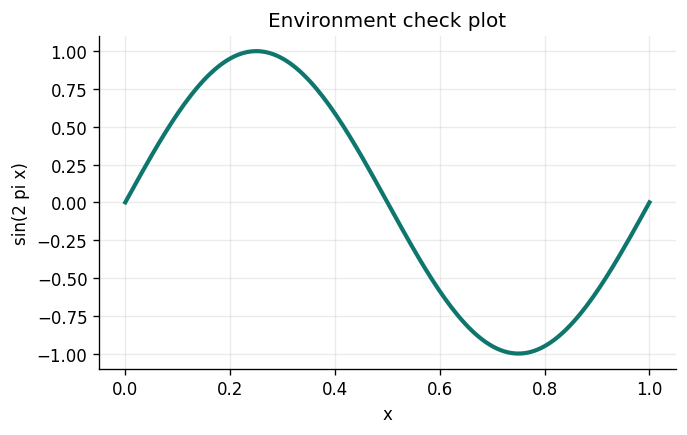

Caption: this small figure proves that cached-mode plotting works in this environment.
assets/figures/environment_check.png


In [10]:
x = np.linspace(0, 1, 160)
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(x, np.sin(2*np.pi*x), lw=2.5, color="#0f766e")
ax.set_title("Environment check plot")
ax.set_xlabel("x")
ax.set_ylabel("sin(2 pi x)")
ax.grid(alpha=0.25)
path = FIGURE_DIR / "environment_check.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.show()
print("Caption: this small figure proves that cached-mode plotting works in this environment.")
print(path.relative_to(PROJECT_ROOT))

## 7. Decision rule for the rest of the course

If core packages pass, use cached mode. If optional packages pass and the instructor has tested runtime, selected demos may switch to `tiny` or `research` mode.

In [11]:
summary = pd.DataFrame({
    "layer": ["core cached mode", "optional research mode"],
    "pass_condition": ["all core imports OK", "selected package imports and runtime tests OK"],
    "classroom_action": ["proceed", "use only if pre-tested"]
})
summary

,layer,pass_condition,classroom_action
0,core cached mode,all core imports OK,proceed
1,optional research mode,selected package imports and runtime tests OK,use only if pre-tested


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

,package,available,version_or_error
0,numpy,1,2.4.4
1,scipy,1,1.17.1
2,matplotlib,1,3.10.8
3,pandas,1,3.0.2
4,xarray,1,2025.3.0
5,netCDF4,1,1.7.3
6,h5py,1,3.16.0
7,plotly,1,6.7.0
8,nbformat,1,5.10.4
9,pytest,1,9.0.3


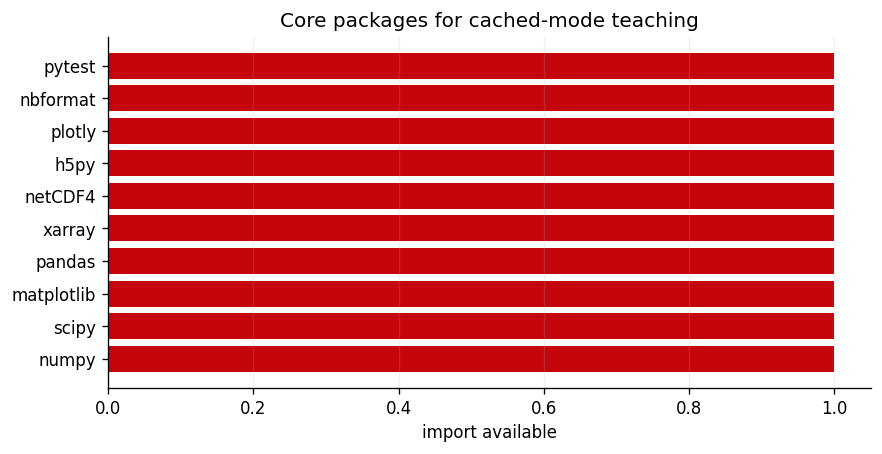

Caption: this check shows whether the local environment can run the cached teaching path before class starts.


In [12]:
import importlib
packages = ["numpy", "scipy", "matplotlib", "pandas", "xarray", "netCDF4", "h5py", "plotly", "nbformat", "pytest"]
status = []
for package in packages:
    try:
        module = importlib.import_module(package)
        status.append((package, 1, getattr(module, "__version__", "installed")))
    except Exception as exc:
        status.append((package, 0, type(exc).__name__))
summary = pd.DataFrame(status, columns=["package", "available", "version_or_error"])
display(summary)
fig, ax = plt.subplots(figsize=(8.2, 3.8))
colors = ["#c5050c" if value else "#b7b7b7" for value in summary["available"]]
ax.barh(summary["package"], summary["available"], color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel("import available")
ax.set_title("Core packages for cached-mode teaching")
ax.grid(axis="x", alpha=0.2)
plt.show()
print("Caption: this check shows whether the local environment can run the cached teaching path before class starts.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one optional import name to a package you know is absent and rerun the optional table.

## Expected qualitative answer
The optional table should report a failure without breaking cached mode.

## Research extension
Add a package-specific runtime smoke test, but keep it non-fatal for students.